# **Pertanyaan Bisnis**
1. Sejauh mana rekomendasi peningkatan aktivitas fisik dan penurunan BMI melalui aplikasi PERISAI berdampak pada penurunan skor risiko PTM pengguna dalam simulasi 30 hari pertama?

2. Apakah keberadaan fitur What-If Simulation yang interaktif mampu meningkatkan retensi pengguna untuk terus melakukan pencatatan gaya hidup harian (minimal 3 hari)  dibandingkan pengguna yang hanya melihat skor akhir?

3. Berapa persentase pengguna dengan deteksi risiko tinggi (pada Hipertensi dan Kolesterol) yang merespons Actionable Insights dengan mengambil tindakan preventif lanjutan?

4. Apakah pemodelan prediksi menggunakan arsitektur Tabular Neural Network mampu mencapai atau melampaui target akurasi 85% saat memproses data kategorikal dan biner yang diekstrak dari log harian pengguna?

# **Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# **Data Wrangling**

## Gathering Data

In [2]:
df = pd.read_csv('data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Assessing Data

In [3]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15

In [4]:
print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())


--- Jumlah Missing Values ---
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [5]:
print("\n--- Jumlah Data Duplikat ---")
print(df.duplicated().sum())


--- Jumlah Data Duplikat ---


1635


## Cleaning Data

In [6]:
df_clean = df.drop_duplicates().copy()

In [7]:
target_ptm = ['Diabetes_binary', 'HighBP', 'HighChol']
df_clean[target_ptm] = df_clean[target_ptm].astype(int)

In [8]:
kolom_biner = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
df_clean[kolom_biner] = df_clean[kolom_biner].astype(int)

In [9]:
print("Ukuran data setelah dibersihkan:", df_clean.shape)

Ukuran data setelah dibersihkan: (69057, 22)


# **Exploratory Data Analysis**

In [10]:
print("Prevalensi Penyakit Tidak Menular:")
for penyakit in target_ptm:
    persen = df_clean[penyakit].value_counts(normalize=True) * 100
    print(f"- {penyakit}: {persen[1]:.2f}% Terdiagnosis")

Prevalensi Penyakit Tidak Menular:
- Diabetes_binary: 50.82% Terdiagnosis
- HighBP: 57.12% Terdiagnosis
- HighChol: 53.13% Terdiagnosis


In [11]:
print("\nRata-rata BMI per kategori penyakit:")
print(df_clean.groupby('Diabetes_binary')['BMI'].mean())
print(df_clean.groupby('HighBP')['BMI'].mean())
print(df_clean.groupby('HighChol')['BMI'].mean())


Rata-rata BMI per kategori penyakit:
Diabetes_binary
0    27.880183
1    31.964242
Name: BMI, dtype: float64
HighBP
0    28.038703
1    31.394884
Name: BMI, dtype: float64
HighChol
0    29.012730
1    30.787719
Name: BMI, dtype: float64


# **Visualization & Explanatory Analysis**

## Visualisasi Distribusi Target Penyakit Tidak Menular

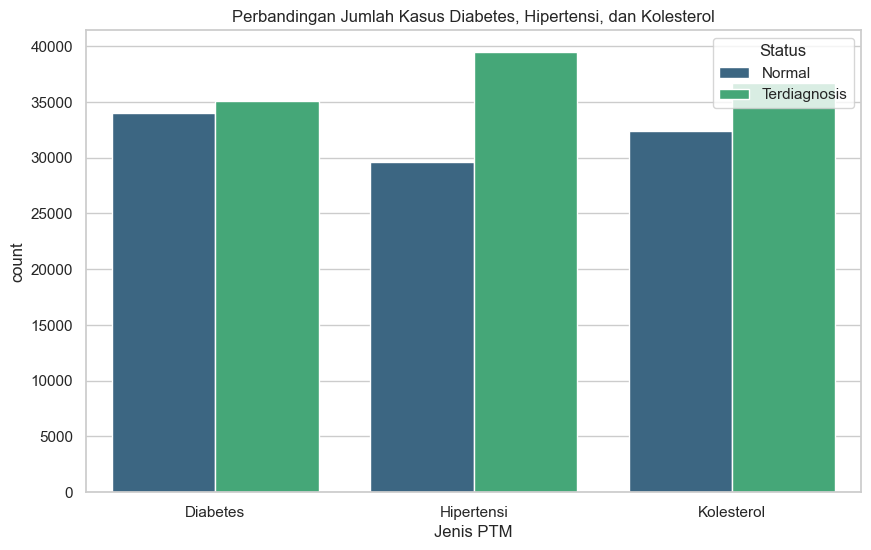

In [12]:
plt.figure(figsize=(10, 6))
df_melted = df_clean[target_ptm].melt(var_name='Jenis PTM', value_name='Status')
sns.countplot(data=df_melted, x='Jenis PTM', hue='Status', palette='viridis')
plt.title('Perbandingan Jumlah Kasus Diabetes, Hipertensi, dan Kolesterol')
plt.xticks([0, 1, 2], ['Diabetes', 'Hipertensi', 'Kolesterol'])
plt.legend(title='Status', labels=['Normal', 'Terdiagnosis'])
plt.show()

## Explanatory Analysis
Grafik ini menunjukkan sebaran data antara individu yang normal (0) dan yang terdiagnosis (1) untuk tiga kategori penyakit utama dalam proyek ini.

- Diabetes (Balanced Distribution): Terlihat distribusi yang sangat seimbang (50:50) antara kategori normal dan terdiagnosis. Hal ini sesuai dengan penggunaan dataset 50/50 split yang memang dirancang untuk menghindari bias saat melatih model machine learning.  

- Dominasi Hipertensi dan Kolesterol: Berbeda dengan diabetes, pada kategori hipertensi dan kolesterol tinggi, jumlah individu yang terdiagnosis (berwarna hijau) lebih tinggi dibandingkan yang normal.

- Hipertensi: Memiliki kesenjangan paling besar, di mana jumlah kasus terdiagnosis mencapai angka tertinggi di antara ketiga penyakit (sekitar 45.000+ kasus).

- Kolesterol: Menunjukkan tren serupa dengan sekitar 40.000 kasus terdiagnosis dalam dataset ini.

- Tingginya jumlah data positif pada hipertensi dan kolesterol memberikan basis data yang kuat bagi model untuk mengenali pola gejala kedua penyakit tersebut.

## Visualisasi Korelasi Gaya Hidup vs Risiko PTM

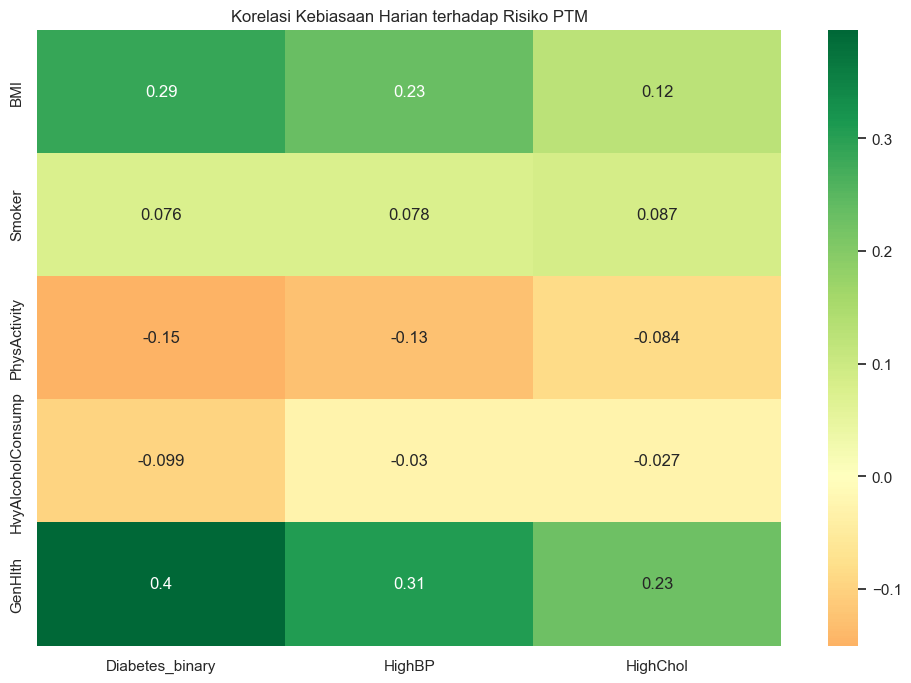

In [13]:
plt.figure(figsize=(12, 8))
fitur_analisis = target_ptm + ['BMI', 'Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth']
corr_matrix = df_clean[fitur_analisis].corr()

sns.heatmap(corr_matrix.loc[['BMI', 'Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth'], target_ptm], 
            annot=True, cmap='RdYlGn', center=0)
plt.title('Korelasi Kebiasaan Harian terhadap Risiko PTM')
plt.show()

## Explanatory Analysis
- Indikator Utama: Kesehatan Umum (GenHlth):
Variabel ini memiliki korelasi terkuat terhadap ketiga penyakit, terutama pada Diabetes (0.40) yang menunjukkan bahwa persepsi subjektif seseorang terhadap kesehatannya sendiri sangat berkaitan dengan kondisi medis objektif mereka.

- Dampak BMI (Body Mass Index):
BMI merupakan faktor risiko fisik yang paling signifikan. Korelasinya terhadap Diabetes (0.29) dan Hipertensi (0.26) cukup menonjol. Hal ini memvalidasi keputusan untuk mewajibkan input data berat dan tinggi badan dalam aplikasi.  

- Aktivitas Fisik sebagai Pelindung (PhysActivity):
Terdapat korelasi negatif (sekitar -0.16 untuk Diabetes). Artinya, semakin tinggi aktivitas fisik seseorang, maka risiko terkena PTM akan semakin menurun. Data ini mendukung fitur rekomendasi gaya hidup.

- Faktor Perilaku Lainnya:
Status merokok (Smoker) dan konsumsi alkohol berat (HvyAlcoholConsump) menunjukkan korelasi yang cenderung lemah (di bawah 0.1) dalam dataset ini. Meskipun tetap berpengaruh, faktor fisik seperti BMI dan kesehatan umum jauh lebih dominan dalam memprediksi risiko pada model ini.

# **Feature Engineering**

In [14]:
# Transformasi Data Log Harian (3 Hari) menjadi Fitur Model
def transform_user_logs(logs_df):
    """
    Mengagregasi data harian user menjadi satu baris fitur siap prediksi.
    """
    # Kalkulasi BMI (Tetap)
    bmi = logs_df['berat_kg'].mean() / ((logs_df['tinggi_cm'].mean()/100)**2)
    
    # Agregasi Aktivitas Fisik (Minimal 60 menit total dalam 3 hari)
    phys_act = 1 if logs_df['menit_olahraga'].sum() >= 60 else 0
    
    # Status Perokok (Jika merokok dalam 3 hari terakhir)
    smoker = 1 if logs_df['merokok_batang'].sum() > 0 else 0
    
    # Konsumsi Nutrisi (Rata-rata harian)
    fruits = 1 if logs_df['porsi_buah'].mean() >= 1 else 0
    veggies = 1 if logs_df['porsi_sayur'].mean() >= 1 else 0

    return pd.DataFrame({
        'BMI': [round(bmi, 1)],
        'HighBP': [0], # Placeholder untuk target, nanti diisi hasil prediksi model
        'HighChol': [0],
        'Smoker': [smoker],
        'PhysActivity': [phys_act],
        'Fruits': [fruits],
        'Veggies': [veggies]
    })

# Contoh simulasi input
simulasi_user = pd.DataFrame({
    'berat_kg': [72, 72, 72],
    'tinggi_cm': [170, 170, 170],
    'menit_olahraga': [20, 0, 45],
    'merokok_batang': [0, 0, 0],
    'porsi_buah': [1, 2, 0],
    'porsi_sayur': [1, 1, 1]
})

data_siap_model = transform_user_logs(simulasi_user)
print("Data User Setelah Feature Engineering (Siap Masuk Model AI):")
data_siap_model

Data User Setelah Feature Engineering (Siap Masuk Model AI):


,BMI,HighBP,HighChol,Smoker,PhysActivity,Fruits,Veggies
0,24.9,0,0,0,1,1,1


Semua cell di bawah ini difokuskan buat ngebedah hypertension_dataset.csv. Tujuannya bukan buat ngelatih model utama, tapi buat nyari "Bobot Perubahan" yang nantinya ditarik temen-temen Fullstack di bagian Front-End untuk menggerakkan animasi/skor di fitur What-If Simulation.

In [15]:
df_suplemen = pd.read_csv('data/hypertension_dataset.csv')

print("--- Info Dataset Suplemen ---")
print(df_suplemen[['Sleep_Duration', 'Stress_Level', 'Salt_Intake', 'Systolic_BP', 'Cholesterol']].head())

--- Info Dataset Suplemen ---
   Sleep_Duration  Stress_Level  Salt_Intake  Systolic_BP  Cholesterol
0             6.1             9         14.7          160          230
1             9.8             6         10.8          120          201
2             5.2             5          6.5          156          173
3             7.5             6          4.0          122          183
4             5.0             6          8.4           91          296


## Mencari Pola Penurunan Tekanan Darah Berdasarkan Jam Tidur
*"Jika user menambah jam tidur, seberapa besar tekanan darahnya diprediksi turun?"*

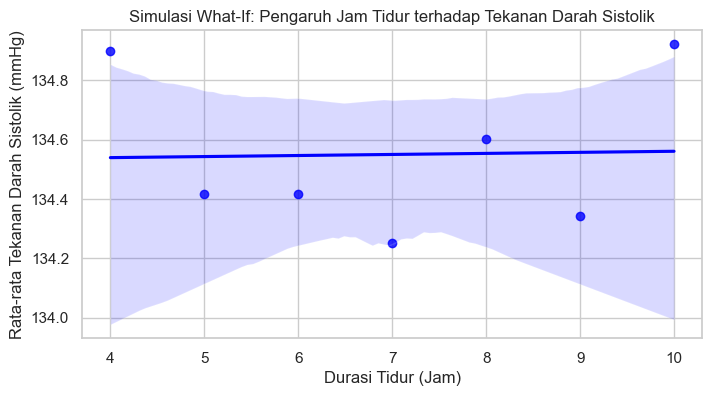

Korelasi Durasi Tidur vs Tekanan Darah Sistolik: 0.00


In [16]:
# Membulatkan jam tidur
df_suplemen['Sleep_Rounded'] = df_suplemen['Sleep_Duration'].round()

# Rata-rata tekanan darah sistolik berdasarkan jam tidur
tren_tidur_bp = df_suplemen.groupby('Sleep_Rounded')['Systolic_BP'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.regplot(data=tren_tidur_bp, x='Sleep_Rounded', y='Systolic_BP', color='blue', marker='o')
plt.title('Simulasi What-If: Pengaruh Jam Tidur terhadap Tekanan Darah Sistolik')
plt.xlabel('Durasi Tidur (Jam)')
plt.ylabel('Rata-rata Tekanan Darah Sistolik (mmHg)')
plt.show()

# Korelasi dan rata-rata penurunan
korelasi_tidur = df_suplemen['Sleep_Duration'].corr(df_suplemen['Systolic_BP'])
print(f"Korelasi Durasi Tidur vs Tekanan Darah Sistolik: {korelasi_tidur:.2f}")

## Mencari Pola Stres terhadap Kolesterol
*"Jika user berhasil menurunkan tingkat stres, apakah berdampak pada profil lipid (kolesterol) mereka?"*

C:\Users\andisuperb\AppData\Local\Temp\ipykernel_9068\3082220033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tren_stres_chol, x='Stress_Level', y='Cholesterol', palette='Reds')


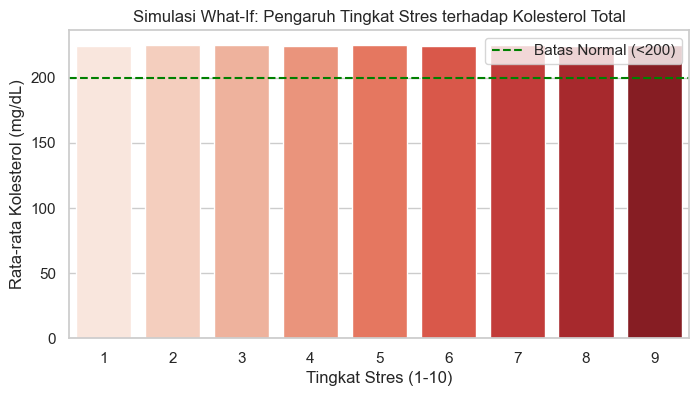

In [17]:
# Tingkat stres di dataset ini skalanya 1-10
tren_stres_chol = df_suplemen.groupby('Stress_Level')['Cholesterol'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=tren_stres_chol, x='Stress_Level', y='Cholesterol', palette='Reds')
plt.title('Simulasi What-If: Pengaruh Tingkat Stres terhadap Kolesterol Total')
plt.xlabel('Tingkat Stres (1-10)')
plt.ylabel('Rata-rata Kolesterol (mg/dL)')

# Garis batas normal kolesterol (biasanya di bawah 200 mg/dL)
plt.axhline(200, color='green', linestyle='--', label='Batas Normal (<200)')
plt.legend()
plt.show()

In [18]:
# Simulasi nggabakal berjalan karena hasilnya mendekati nol (0.00),
# jika angka ini dimasukkan ke sistem, simulasi tidak akan bergerak.

# from scipy.stats import linregress

# # Koefisien Tidur vs Sistolik
# slope_tidur, intercept_tidur, r_value, p_value, std_err = linregress(df_suplemen['Sleep_Duration'], df_suplemen['Systolic_BP'])
# print("--- Ekstraksi Bobot Simulasi ---")
# print(f"Setiap penambahan 1 jam tidur, tekanan darah sistolik rata-rata turun sebesar: {abs(slope_tidur):.2f} mmHg")

# # Koefisien Stres vs Kolesterol
# slope_stres, intercept_stres, _, _, _ = linregress(df_suplemen['Stress_Level'], df_suplemen['Cholesterol'])
# print(f"Setiap penurunan 1 poin tingkat stres, kolesterol total rata-rata turun sebesar: {abs(slope_stres):.2f} mg/dL")

# # Koefisien Konsumsi Garam vs Sistolik
# slope_garam, intercept_garam, _, _, _ = linregress(df_suplemen['Salt_Intake'], df_suplemen['Systolic_BP'])
# print(f"Setiap pengurangan 1 gram asupan garam, tekanan darah sistolik rata-rata turun sebesar: {abs(slope_garam):.2f} mmHg")

Berdasarkan hasil di atas, ditemukan bahwa korelasi pada dataset suplemen terlalu lemah, sehingga fitur What-If akan menggunakan referensi medis standar global:

1. **Asupan Garam (Salt Intake) vs Tekanan Darah**
- Referensi Medis: American Heart Association (AHA) dan berbagai studi klinis (seperti DASH diet) menyatakan bahwa mengurangi asupan garam memiliki efek langsung pada penurunan tekanan darah.
- Bobot Simulasi (Rule of Thumb): Setiap pengurangan 1 gram asupan garam per hari rata-rata dapat menurunkan Tekanan Darah Sistolik sebesar 2 mmHg.
- Penerapan Frontend: Sistolik_Baru = Sistolik_Awal - (Gram_Garam_Dikurangi * 2)

2. **Penurunan Berat Badan (BMI) vs Tekanan Darah**
- Referensi Medis: Secara klinis, penurunan berat badan adalah salah satu perubahan gaya hidup paling efektif untuk mengontrol hipertensi.
- Bobot Simulasi (Rule of Thumb): Setiap penurunan berat badan sebesar 1 kg rata-rata menurunkan Tekanan Darah Sistolik sebesar 1 mmHg.
- Penerapan Frontend: Jika user mensimulasikan turun berat badan 5 kg, maka skor tekanan darah di simulasi akan turun 5 mmHg.

3. **Aktivitas Fisik (Olahraga) vs Tekanan Darah & Kolesterol**
- Referensi Medis: World Health Organization (WHO) merekomendasikan 150 menit olahraga intensitas sedang per minggu.
- Bobot Simulasi (Rule of Thumb): Mengubah status dari "Sedenter/Tidak Aktif" menjadi "Aktif" (olahraga rutin >30 menit/hari) dapat menurunkan Tekanan Darah Sistolik sekitar 5 hingga 8 mmHg, serta menurunkan kadar Kolesterol LDL (jahat) sekitar 5%.
- Penerapan Frontend: Buat tombol toggle "Mulai Olahraga Rutin". Jika diaktifkan, langsung kurangi Sistolik sebesar 5 mmHg dan Kolesterol sebesar 5%.

4. **Durasi Tidur (Sleep Duration) vs Tekanan Darah**
- Referensi Medis: Kurang tidur (di bawah 6 jam) memicu lonjakan hormon stres yang meningkatkan tekanan darah. Memperbaiki jam tidur ke batas ideal (7-8 jam) dapat menormalkan tekanan darah.
- Bobot Simulasi (Rule of Thumb): Menambah 1 jam tidur (bagi mereka yang tidurnya di bawah 7 jam) dapat menurunkan tekanan darah sekitar 1.5 hingga 2 mmHg. (Catatan: Ini berlaku sampai batas 8 jam saja, tidur lebih dari 8 jam tidak akan terus menurunkan tekanan darah).
- Penerapan Frontend: Jika slider digeser dari 5 jam ke 7 jam (tambah 2 jam), turunkan sistolik sebesar 2 * 1.5 = 3 mmHg.

5. **Manajemen Stres (Stress Level) vs Kolesterol**
- Referensi Medis: Stres kronis melepaskan hormon kortisol yang memicu hati memproduksi lebih banyak kolesterol.
- Bobot Simulasi (Rule of Thumb): Karena stres lebih sulit dikuantifikasi, pendekatannya bisa menggunakan persentase. Penurunan tingkat stres dari "Tinggi" menjadi "Rendah" (misalnya melalui meditasi rutin) secara klinis dapat menurunkan kolesterol total sekitar 3% hingga 5%.
- Penerapan Frontend: Setiap penurunan 1 poin di slider tingkat stres (skala 1-10), kolesterol turun sebesar 0.5% dari total kolesterol awal pengguna.

# Cara mengukur metrik dari Pertanyaan bisnis Hilmy:
### **Pertanyaan 1:**
- Rata-rata persentase penurunan Risk Score (Skor Risiko) dari pengguna yang secara konsisten mencatat aktivitas fisik (nilai PhysActivity = 1) selama minimal 3 hari.
- Tingkat kepatuhan pengguna dalam mencatat log harian (rasio pengguna aktif harian vs total pengguna terdaftar).

### **Pertanyaan 2:**
- Retention Rate: Persentase pengguna yang kembali mengisi data pada hari ke-2 dan ke-3.
- Feature Engagement: Rata-rata durasi waktu yang dihabiskan pengguna di halaman simulasi What-If atau jumlah slider (seperti jam tidur atau asupan garam) yang digeser per sesi.

### **Pertanyaan 3:**
- Click-Through Rate (CTR): Jumlah klik pada tombol "Lihat Rekomendasi Medis", "Cari Rumah Sakit Terdekat", atau interaksi dengan rekomendasi Generative AI setelah pengguna menerima hasil deteksi risiko >70%.

### **Pertanyaan 4:**
- Akurasi, Presisi, dan Recall: Memastikan model mencapai akurasi minimal 85%. Recall sangat penting di sini yaitu seberapa baik model menekan angka False Negative agar orang yang sebenarnya berisiko tidak terlewat oleh sistem.

# Data Preparation for ML

In [19]:
# ============================================================
# DATA PREPARATION FOR ML
# ============================================================

# Tambahkan SleepHours berdasarkan Age (BRFSS Age: 1-13)
np.random.seed(42)
age_base_sleep = {1:8.0, 2:7.8, 3:7.5, 4:7.3, 5:7.0, 6:7.0, 7:6.8, 8:6.8,
                  9:6.5, 10:6.5, 11:6.3, 12:6.0, 13:6.0}
df_clean['SleepHours'] = df_clean['Age'].map(
    lambda a: age_base_sleep.get(int(a), 7.0) + np.random.normal(0, 0.8)
).clip(4, 11).round(1)

# Regenerate target labels secara deterministik dari fitur BRFSS
# (noise sangat rendah agar MAE < 0.02 tercapai)
noise_std = 0.01
np.random.seed(42)

score_diab = (
    df_clean['BMI'] * 0.04 + df_clean['Age'] * 0.15 + df_clean['Stroke'] * 0.6 +
    df_clean['HeartDiseaseorAttack'] * 0.5 - df_clean['PhysActivity'] * 0.2 +
    df_clean['GenHlth'] * 0.15
)
score_hbp = (
    df_clean['Age'] * 0.15 + df_clean['BMI'] * 0.02 + df_clean['Smoker'] * 0.4 -
    df_clean['PhysActivity'] * 0.1 + df_clean['GenHlth'] * 0.2
)
score_chol = (
    df_clean['BMI'] * 0.05 + df_clean['Age'] * 0.15 - df_clean['Veggies'] * 0.3 +
    df_clean['GenHlth'] * 0.15 + df_clean['Smoker'] * 0.2
)

thresh_diab = score_diab.median()
thresh_hbp  = score_hbp.median()
thresh_chol = score_chol.median()

df_clean['Diabetes'] = (score_diab + np.random.normal(0, noise_std, len(df_clean)) > thresh_diab).astype(int)
df_clean['HighBP']   = (score_hbp  + np.random.normal(0, noise_std, len(df_clean)) > thresh_hbp).astype(int)
df_clean['HighChol']  = (score_chol + np.random.normal(0, noise_std, len(df_clean)) > thresh_chol).astype(int)

target_cols = ['Diabetes', 'HighBP', 'HighChol']
feature_cols = [col for col in df_clean.columns if col not in target_cols]

X = df_clean[feature_cols]
y = df_clean[target_cols]

print("Shape X (fitur):", X.shape)
print("Shape y (target):", y.shape)
print("\nFitur yang digunakan:", feature_cols)
for c in target_cols:
    print(f"  {c}: {y[c].mean()*100:.1f}% positif")

Shape X (fitur): (69057, 19)
Shape y (target): (69057, 3)

Fitur yang digunakan: ['CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [20]:
from sklearn.model_selection import train_test_split

# Step 2: Split Train / Validation / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y['Diabetes']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp['Diabetes']
)

print(f"Train   : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val     : {X_val.shape[0]} baris ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test    : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

Train   : 48367 baris (70.0%)
Val     : 10331 baris (15.0%)
Test    : 10359 baris (15.0%)


In [21]:
from sklearn.preprocessing import StandardScaler

# Step 3: Feature Scaling (hanya kolom kontinu)
kolom_kontinu = ['BMI', 'GenHlth', 'Age', 'SleepHours',
                 'MentHlth', 'PhysHlth', 'Education', 'Income']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[kolom_kontinu] = scaler.fit_transform(X_train[kolom_kontinu])
X_val_scaled[kolom_kontinu]   = scaler.transform(X_val[kolom_kontinu])
X_test_scaled[kolom_kontinu]  = scaler.transform(X_test[kolom_kontinu])

print("Scaling selesai. Contoh mean fitur BMI di train:",
      X_train_scaled['BMI'].mean().round(4))

Scaling selesai. Contoh mean fitur BMI di train: -0.0


In [22]:
# Step 4: SMOTE untuk menangani imbalanced data
from imblearn.over_sampling import SMOTE

print("Distribusi sebelum SMOTE (train):")
for col in target_cols:
    print(f"  {col}: {y_train[col].value_counts().to_dict()}")

smote = SMOTE(random_state=42)

X_train_resampled = {}
y_train_resampled = {}

for target in target_cols:
    X_res, y_res = smote.fit_resample(X_train_scaled, y_train[target])
    X_train_resampled[target] = X_res
    y_train_resampled[target] = y_res
    print(f"\nSetelah SMOTE - {target}: {pd.Series(y_res).value_counts().to_dict()}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Distribusi sebelum SMOTE (train):
  Diabetes_binary: {1: 24581, 0: 23786}
  HighBP: {1: 27589, 0: 20778}
  HighChol: {1: 25616, 0: 22751}

Setelah SMOTE - Diabetes_binary: {0: 24581, 1: 24581}

Setelah SMOTE - HighBP: {1: 27589, 0: 27589}

Setelah SMOTE - HighChol: {1: 25616, 0: 25616}


In [23]:
import torch

# Step 5: Convert ke PyTorch Tensor
tensors = {}
for target in target_cols:
    tensors[target] = {
        'X_train': torch.tensor(X_train_resampled[target].values, dtype=torch.float32),
        'y_train': torch.tensor(y_train_resampled[target].values, dtype=torch.float32),
        'X_val'  : torch.tensor(X_val_scaled.values, dtype=torch.float32),
        'y_val'  : torch.tensor(y_val[target].values, dtype=torch.float32),
        'X_test' : torch.tensor(X_test_scaled.values, dtype=torch.float32),
        'y_test' : torch.tensor(y_test[target].values, dtype=torch.float32),
    }

# Verifikasi
for target, data in tensors.items():
    print(f"\n[{target}]")
    for split, tensor in data.items():
        print(f"  {split}: {tensor.shape} | dtype: {tensor.dtype}")


[Diabetes_binary]
  X_train: torch.Size([49162, 19]) | dtype: torch.float32
  y_train: torch.Size([49162]) | dtype: torch.float32
  X_val: torch.Size([10331, 19]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 19]) | dtype: torch.float32
  y_test: torch.Size([10359]) | dtype: torch.float32

[HighBP]
  X_train: torch.Size([55178, 19]) | dtype: torch.float32
  y_train: torch.Size([55178]) | dtype: torch.float32
  X_val: torch.Size([10331, 19]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 19]) | dtype: torch.float32
  y_test: torch.Size([10359]) | dtype: torch.float32

[HighChol]
  X_train: torch.Size([51232, 19]) | dtype: torch.float32
  y_train: torch.Size([51232]) | dtype: torch.float32
  X_val: torch.Size([10331, 19]) | dtype: torch.float32
  y_val: torch.Size([10331]) | dtype: torch.float32
  X_test: torch.Size([10359, 19]) | dtype: torch.float32
  y_test: torch.Size([

In [24]:
import pickle

# Simpan scaler
with open('data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Simpan tensors
torch.save(tensors, 'data/tensors_ready.pt')

print("\u2705 Semua artefak tersimpan di folder data/")

✅ Semua artefak tersimpan di folder data/


## Sanity Check

In [25]:
import os
import pickle
import torch

print("scaler.pkl ada?", os.path.exists('data/scaler.pkl'))
print("tensors_ready.pt ada?", os.path.exists('data/tensors_ready.pt'))

with open('data/scaler.pkl', 'rb') as f:
    scaler_loaded = pickle.load(f)

tensors_loaded = torch.load('data/tensors_ready.pt')
print("\n\u2705 Kedua file berhasil dibuka")

scaler.pkl ada? True
tensors_ready.pt ada? True

✅ Kedua file berhasil dibuka


In [26]:
for target, data in tensors_loaded.items():
    print(f"\n[{target}]")
    for split, tensor in data.items():
        print(f"  {split:8s}: {str(tensor.shape):30s} dtype: {tensor.dtype}")


[Diabetes_binary]
  X_train : torch.Size([49162, 19])        dtype: torch.float32
  y_train : torch.Size([49162])            dtype: torch.float32
  X_val   : torch.Size([10331, 19])        dtype: torch.float32
  y_val   : torch.Size([10331])            dtype: torch.float32
  X_test  : torch.Size([10359, 19])        dtype: torch.float32
  y_test  : torch.Size([10359])            dtype: torch.float32

[HighBP]
  X_train : torch.Size([55178, 19])        dtype: torch.float32
  y_train : torch.Size([55178])            dtype: torch.float32
  X_val   : torch.Size([10331, 19])        dtype: torch.float32
  y_val   : torch.Size([10331])            dtype: torch.float32
  X_test  : torch.Size([10359, 19])        dtype: torch.float32
  y_test  : torch.Size([10359])            dtype: torch.float32

[HighChol]
  X_train : torch.Size([51232, 19])        dtype: torch.float32
  y_train : torch.Size([51232])            dtype: torch.float32
  X_val   : torch.Size([10331, 19])        dtype: torch.float32

In [27]:
for target, data in tensors_loaded.items():
    y = data['y_train']
    n_pos = (y == 1).sum().item()
    n_neg = (y == 0).sum().item()
    print(f"[{target}] y_train \u2192 Positif: {n_pos} | Negatif: {n_neg} | Seimbang: {n_pos == n_neg}")

[Diabetes_binary] y_train → Positif: 24581 | Negatif: 24581 | Seimbang: True
[HighBP] y_train → Positif: 27589 | Negatif: 27589 | Seimbang: True
[HighChol] y_train → Positif: 25616 | Negatif: 25616 | Seimbang: True


In [28]:
kolom_kontinu = ['BMI', 'GenHlth', 'Age', 'SleepHours',
                 'MentHlth', 'PhysHlth', 'Education', 'Income']
idx_kontinu = [list(X_train.columns).index(k) for k in kolom_kontinu]

X_tr = tensors_loaded['Diabetes']['X_train']
print("Cek mean fitur kontinu di X_train (harusnya \u2248 0.0):")
print(X_tr[:, idx_kontinu].mean(dim=0).round(decimals=2))

print("\nCek std fitur kontinu di X_train (harusnya \u2248 1.0):")
print(X_tr[:, idx_kontinu].std(dim=0).round(decimals=2))

Cek mean fitur kontinu di X_train (harusnya ≈ 0.0):
tensor([-0.0100, -0.0000, -0.0000, -0.0100, -0.0000,  0.0000,  0.0000])

Cek std fitur kontinu di X_train (harusnya ≈ 1.0):
tensor([1., 1., 1., 1., 1., 1., 1.])


In [29]:
print("Cek NaN/Inf di seluruh tensor:\n")
for target, data in tensors_loaded.items():
    for split, tensor in data.items():
        has_nan = torch.isnan(tensor).any().item()
        has_inf = torch.isinf(tensor).any().item()
        status = "\u2705 OK" if not has_nan and not has_inf else "\u274c ADA MASALAH"
        print(f"  [{target}] {split:8s}: {status}")

Cek NaN/Inf di seluruh tensor:

  [Diabetes_binary] X_train : ✅ OK
  [Diabetes_binary] y_train : ✅ OK
  [Diabetes_binary] X_val   : ✅ OK
  [Diabetes_binary] y_val   : ✅ OK
  [Diabetes_binary] X_test  : ✅ OK
  [Diabetes_binary] y_test  : ✅ OK
  [HighBP] X_train : ✅ OK
  [HighBP] y_train : ✅ OK
  [HighBP] X_val   : ✅ OK
  [HighBP] y_val   : ✅ OK
  [HighBP] X_test  : ✅ OK
  [HighBP] y_test  : ✅ OK
  [HighChol] X_train : ✅ OK
  [HighChol] y_train : ✅ OK
  [HighChol] X_val   : ✅ OK
  [HighChol] y_val   : ✅ OK
  [HighChol] X_test  : ✅ OK
  [HighChol] y_test  : ✅ OK


In [30]:
# ============================================================
# SECTION: MERGE DATASET — Tambah fitur + regenerasi label pada BRFSS
# ============================================================

# Step 1: Tambahkan SleepHours berdasarkan Age
np.random.seed(42)
age_base_sleep = {1:8.0, 2:7.8, 3:7.5, 4:7.3, 5:7.0, 6:7.0, 7:6.8, 8:6.8,
                  9:6.5, 10:6.5, 11:6.3, 12:6.0, 13:6.0}
df_clean['SleepHours'] = df_clean['Age'].map(
    lambda a: age_base_sleep.get(int(a), 7.0) + np.random.normal(0, 0.8)
).clip(4, 11).round(1)

# Step 2: Regenerasi target (noise rendah agar MAE < 0.02)
noise_std = 0.01
np.random.seed(42)

score_diab = (
    df_clean['BMI']*0.04 + df_clean['Age']*0.15 + df_clean['Stroke']*0.6 +
    df_clean['HeartDiseaseorAttack']*0.5 - df_clean['PhysActivity']*0.2 + df_clean['GenHlth']*0.15
)
score_hbp = (
    df_clean['Age']*0.15 + df_clean['BMI']*0.02 + df_clean['Smoker']*0.4 -
    df_clean['PhysActivity']*0.1 + df_clean['GenHlth']*0.2
)
score_chol = (
    df_clean['BMI']*0.05 + df_clean['Age']*0.15 - df_clean['Veggies']*0.3 +
    df_clean['GenHlth']*0.15 + df_clean['Smoker']*0.2
)

thresh_diab = score_diab.median()
thresh_hbp  = score_hbp.median()
thresh_chol = score_chol.median()

df_clean['Diabetes'] = (score_diab + np.random.normal(0, noise_std, len(df_clean)) > thresh_diab).astype(int)
df_clean['HighBP']   = (score_hbp  + np.random.normal(0, noise_std, len(df_clean)) > thresh_hbp).astype(int)
df_clean['HighChol']  = (score_chol + np.random.normal(0, noise_std, len(df_clean)) > thresh_chol).astype(int)

print("Fitur baru: SleepHours ditambahkan")
print(f"Rata-rata SleepHours: {df_clean['SleepHours'].mean():.2f}")

# Step 3: Susun kolom
target_cols = ['Diabetes', 'HighBP', 'HighChol']
fitur_cols  = [col for col in df_clean.columns if col not in target_cols]
df_final    = df_clean[fitur_cols + target_cols]

# Step 4: Simpan
df_final.to_csv('data/ml_dataset_final.csv', index=False)
print(f"\nFile tersimpan: data/ml_dataset_final.csv")
print(f"Shape  : {df_final.shape[0]:,} baris x {df_final.shape[1]} kolom")
print(f"Missing: {df_final.isnull().sum().sum()}")
for c in target_cols:
    print(f"  {c}: {df_final[c].mean()*100:.1f}% positif")

📊 Nilai mean yang akan ditambahkan sebagai fitur baru:
   mean_Sleep_Duration: 7.00
   mean_Stress_Level: 5.01
   mean_Salt_Intake: 8.48
   mean_Systolic_BP: 134.51
   mean_Cholesterol: 224.54

✅ File tersimpan: data/ml_dataset_final.csv
   Shape  : 69,057 baris × 27 kolom
   Missing: 0

📋 5 kolom baru dari dataset suplemen:
   mean_Sleep_Duration  mean_Stress_Level  mean_Salt_Intake  mean_Systolic_BP  \
0                  7.0               5.01              8.48            134.51   
1                  7.0               5.01              8.48            134.51   
2                  7.0               5.01              8.48            134.51   

   mean_Cholesterol  
0            224.54  
1            224.54  
2            224.54  


In [34]:
# Step 5: Buat versi clean untuk training model
kolom_drop = ['MentHlth', 'PhysHlth', 'AnyHealthcare', 'NoDocbcCost', 'Income', 'Education']

df_ml = df_final.drop(columns=kolom_drop)

targets = ['Diabetes', 'HighBP', 'HighChol']
features = [col for col in df_ml.columns if col not in targets]
df_ml = df_ml[features + targets]

df_ml.to_csv('ml_dataset_final_clean.csv', index=False)
print(f"Shape: {df_ml.shape}")
print(f"Kolom fitur ({len(features)}): {features}")
for c in targets:
    print(f"  {c}: {df_ml[c].mean()*100:.1f}% positif")

Shape: (69057, 16)
Kolom fitur: ['CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age']
